# Task 1. Data analysis

This notebook performs an exploratory data analysis of the seven price series in `spiff_data-2.csv`. The goal is to understand the structure of the data, study the behavior of each series, analyze cross-series relationships, and identify plausible groupings among the assets.

The dataset contains 7 price series. Each series has one internal missing block of 50 days, and all series are jointly missing the final 200 days. Because raw price levels can be dominated by common trends, the analysis below primarily works with simple returns and log-returns, while still using price plots as supporting context.


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sys.path.append(str(Path.cwd().parent))
from config.plot_config import plot_config

plot_config()



In [3]:
def read_data(file_name):
    data_path = Path.cwd().parent / "Data" / file_name
    data = pd.read_csv(data_path, index_col=1)
    data.drop(columns=["Unnamed: 0"], inplace=True)
    return data

prices = read_data("spiff_data-2.csv")
prices.head()


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
1,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
2,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
3,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205
4,6.156401,2.823384,2.096137,10.848804,3.288274,3.901170,7.848061
5,6.124929,2.832798,2.099810,10.860731,3.303694,3.905355,7.883026


## Data quality and structure

The first step is to confirm the shape of the dataset, the types of the columns, and the missing-data pattern. This matters because any return calculation will inherit additional missing values around the gaps.


In [4]:
data_overview = pd.DataFrame({
    "dtype": prices.dtypes.astype(str),
    "missing_values": prices.isna().sum(),
    "missing_share": prices.isna().mean()
})

print(f"Shape: {prices.shape}")
display(data_overview)


Shape: (5456, 7)


,dtype,missing_values,missing_share
gurkor,float64,250,0.045821
guitars,float64,250,0.045821
slingshots,float64,250,0.045821
stocks,float64,250,0.045821
sugar,float64,250,0.045821
water,float64,250,0.045821
tranquillity,float64,250,0.045821


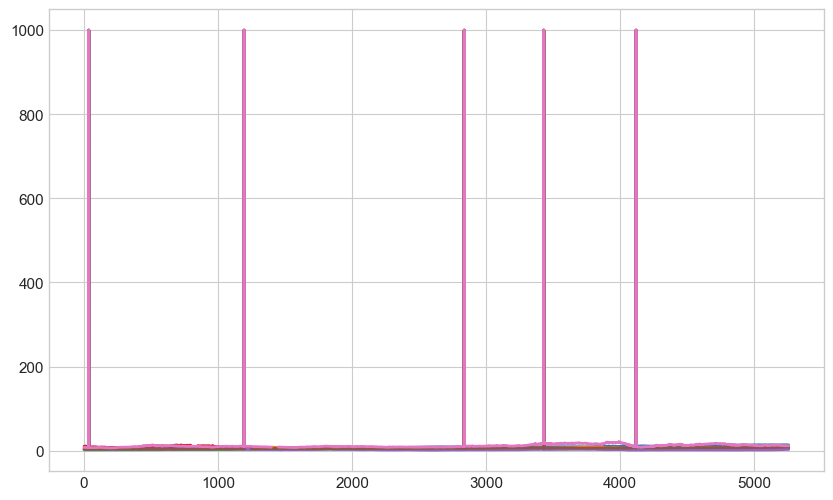

In [5]:
for col in prices.columns:
    plt.plot(prices.index,prices[col])

Before moving on to the missing-data pattern, it is worth checking the clearly implausible observations. A row where every asset suddenly takes exactly the same extreme value would be very unlikely to represent a genuine market move.


These all-1000 rows are best treated as corrupted observations or placeholders rather than real prices. They occur simultaneously across all seven assets and are completely out of scale relative to neighboring days, so the analysis below replaces them with `NaN` and then continues.


In [6]:

placeholder_mask = (prices == 1000).all(axis=1)
placeholder_rows = prices.loc[placeholder_mask]

def clean_data(prices):
    placeholder_mask = (prices == 1000).all(axis=1)
    prices.loc[placeholder_mask] = np.nan
    return prices

prices = clean_data(prices)
cleaned_data_overview = pd.DataFrame({
    "missing_values_after_cleaning": prices.isna().sum(),
    "missing_share_after_cleaning": prices.isna().mean()
})


print(f"Rows where all assets equal 1000: {len(placeholder_rows)}")
display(placeholder_rows)

display(cleaned_data_overview)


Rows where all assets equal 1000: 5


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
36,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
1194,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
2836,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
3430,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
4118,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0


,missing_values_after_cleaning,missing_share_after_cleaning
gurkor,255,0.046738
guitars,255,0.046738
slingshots,255,0.046738
stocks,255,0.046738
sugar,255,0.046738
water,255,0.046738
tranquillity,255,0.046738


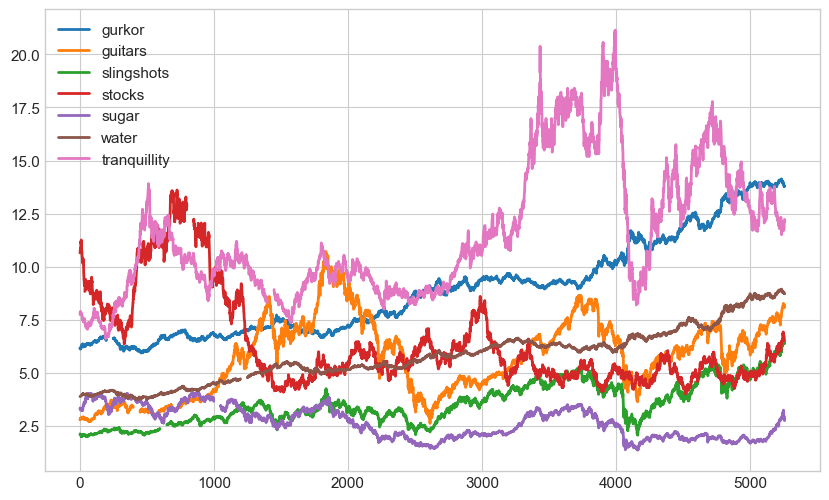

In [7]:
for col in prices.columns:
    plt.plot(prices.index,prices[col],label=col)
plt.legend()

In [8]:
def find_missing_intervals(series):
    missing_index = series.index[series.isna()]
    intervals = []
    start = prev = None

    for idx in missing_index:
        if start is None:
            start = prev = idx
        elif idx == prev + 1:
            prev = idx
        else:
            length = prev - start + 1
            if length > 1:
                intervals.append((start, prev, length))
            start = prev = idx

    if start is not None:
        length = prev - start + 1
        if length > 1:
            intervals.append((start, prev, length))

    return intervals

missing_intervals = {
    column: find_missing_intervals(prices[column])
    for column in prices.columns
}

missing_summary = pd.DataFrame(
    {
        asset: [f"{start}-{end} ({length} days)" for start, end, length in intervals]
        for asset, intervals in missing_intervals.items()
    }
).T
missing_summary.columns = [f"missing_block_{i+1}" for i in range(missing_summary.shape[1])]
missing_summary


,missing_block_1,missing_block_2
gurkor,199-248 (50 days),5257-5456 (200 days)
guitars,399-448 (50 days),5257-5456 (200 days)
slingshots,599-648 (50 days),5257-5456 (200 days)
stocks,799-848 (50 days),5257-5456 (200 days)
sugar,999-1048 (50 days),5257-5456 (200 days)
water,1199-1248 (50 days),5257-5456 (200 days)
tranquillity,1399-1448 (50 days),5257-5456 (200 days)


After replacing the five all-1000 placeholder rows with `NaN`, the missingness pattern is still highly structured rather than random. The internal 50-day gaps are staggered by asset: `199-248`, `399-448`, `599-648`, `799-848`, `999-1048`, `1199-1248`, and `1399-1448`. In addition, every series is missing the final `5257-5456` interval, which means the common forecasting horizon is the same for all assets.


## Transformations

To study dependence and volatility, returns are more informative than absolute price levels. We therefore create both simple returns and log-returns, and use log-returns as the default object for correlation analysis and grouping.


In [9]:
simple_returns = prices.pct_change()
log_returns = np.log(prices / prices.shift(1))
complete_log_returns = log_returns.dropna(how="any")


## Single-series behavior

The next section studies each series individually. Raw price plots show long-run movement, while histograms and rolling volatility plots summarize how noisy the returns are through time.


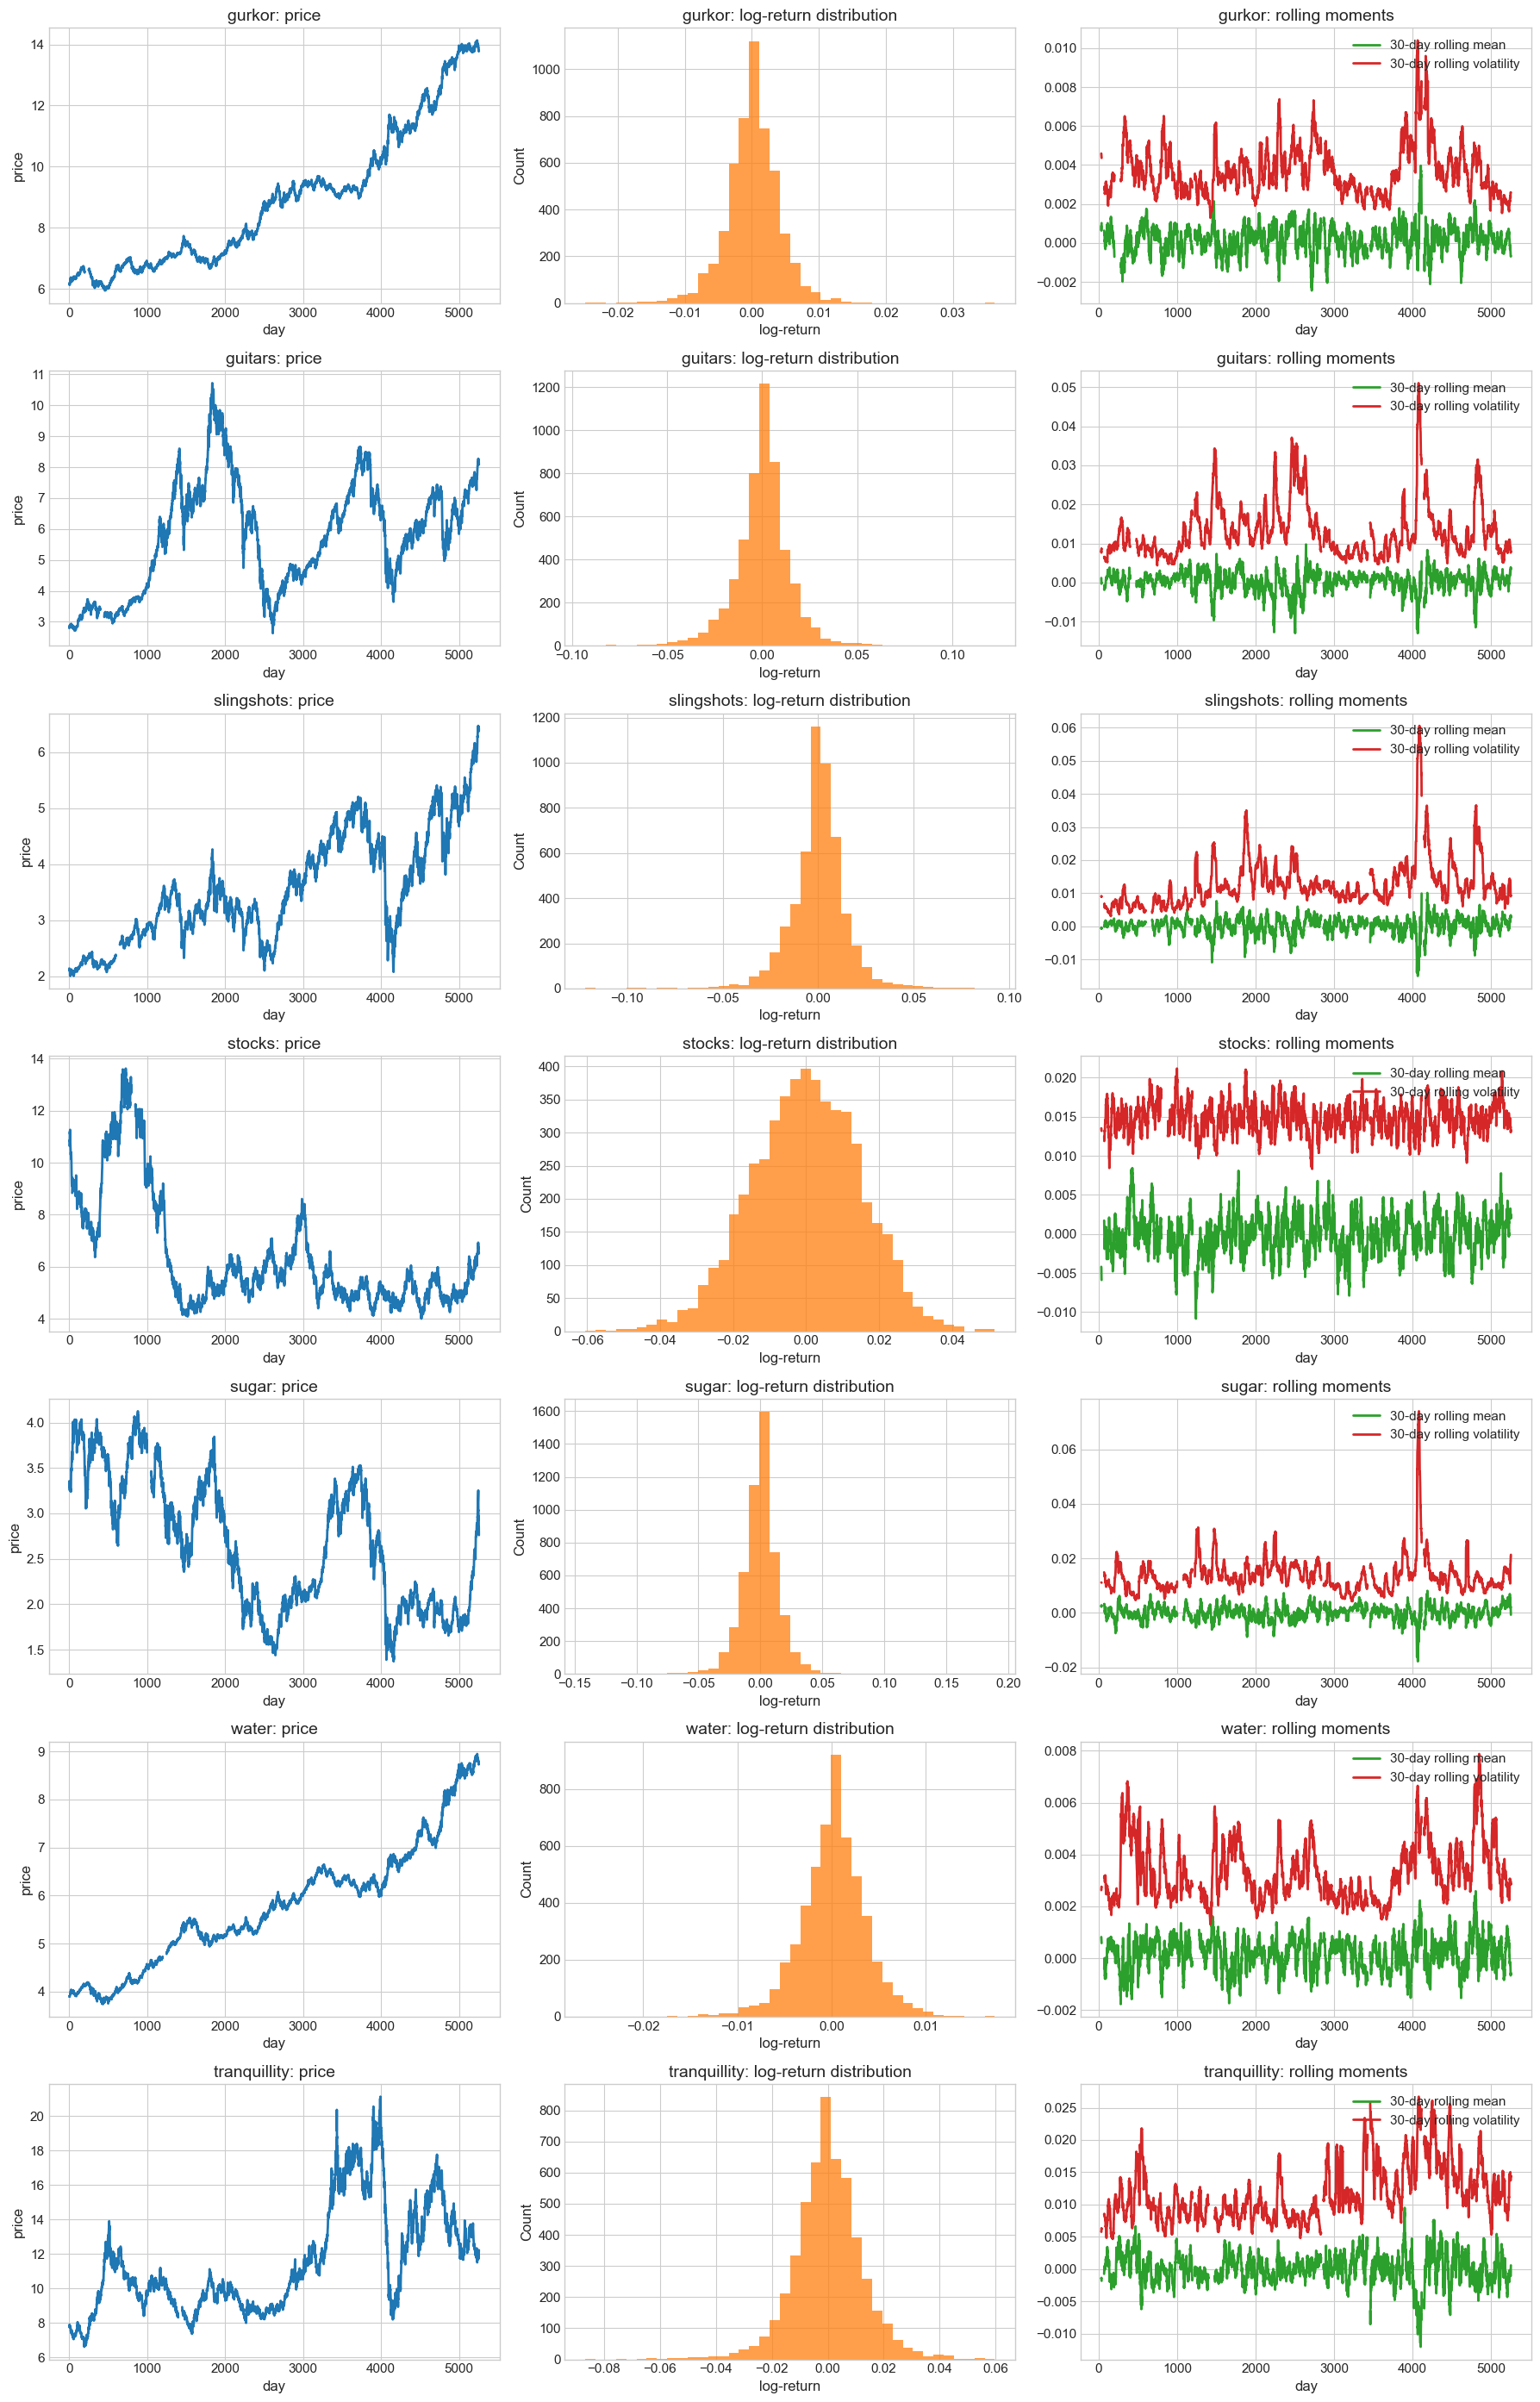

In [10]:
fig, axes = plt.subplots(len(prices.columns), 3, figsize=(18, 4 * len(prices.columns)))
rolling_mean = log_returns.rolling(30).mean()
rolling_vol = log_returns.rolling(30).std()

for row, column in enumerate(prices.columns):
    axes[row, 0].plot(prices.index, prices[column], color="tab:blue")
    axes[row, 0].set_title(f"{column}: price")
    axes[row, 0].set_xlabel("day")
    axes[row, 0].set_ylabel("price")

    sns.histplot(log_returns[column].dropna(), bins=40, ax=axes[row, 1], color="tab:orange", edgecolor=None)
    axes[row, 1].set_title(f"{column}: log-return distribution")
    axes[row, 1].set_xlabel("log-return")

    axes[row, 2].plot(rolling_mean.index, rolling_mean[column], label="30-day rolling mean", color="tab:green")
    axes[row, 2].plot(rolling_vol.index, rolling_vol[column], label="30-day rolling volatility", color="tab:red")
    axes[row, 2].set_title(f"{column}: rolling moments")
    axes[row, 2].set_xlabel("day")
    axes[row, 2].legend(loc="upper right")

plt.tight_layout()
plt.show()


In [11]:
single_series_summary = pd.DataFrame({
    "mean": log_returns.mean(),
    "std": log_returns.std(),
    "min": log_returns.min(),
    "max": log_returns.max(),
    "skewness": log_returns.skew(),
    "kurtosis": log_returns.kurtosis(),
    "avg_30d_vol": rolling_vol.mean()
}).sort_values("std", ascending=False)

single_series_summary


,mean,std,min,max,skewness,kurtosis,avg_30d_vol
sugar,-0.000014,0.015209,-0.141238,0.189156,-0.238585,10.704963,0.013714
stocks,-0.000074,0.014935,-0.060469,0.051696,-0.124211,0.077238,0.014844
guitars,0.000236,0.014876,-0.093062,0.122535,-0.034939,5.558723,0.013234
slingshots,0.000194,0.014747,-0.121902,0.092500,-0.444992,6.438702,0.012904
tranquillity,0.000078,0.012589,-0.086687,0.059772,-0.271848,2.976584,0.011708
gurkor,0.000155,0.003945,-0.024838,0.036285,-0.146980,3.517657,0.003720
water,0.000152,0.003515,-0.026131,0.017331,-0.259686,2.250074,0.003343


### Interpretation of single-series behavior

Once the five placeholder rows are removed, the return series look much more regular and the extreme heavy tails become less dominant. Volatility still differs across assets: `sugar`, `stocks`, `guitars`, and `slingshots` are the noisiest series, while `gurkor` and especially `water` are much smoother. `tranquillity` sits between these groups and looks calmer than the more volatile assets but not as stable as `gurkor` and `water`.

The rolling statistics still suggest time-varying volatility rather than constant volatility. The 30-day rolling volatility changes over time for all series, so a homoskedastic model would still miss an important feature of the data.


## Cross-series relationships

We now compare assets to each other. A useful first contrast is between price-level correlation and return correlation. Price-level correlations can be inflated when several series trend together over time, so return-based correlations are the more informative measure here.


### Autocorrelation of absolute log-returns

To study volatility clustering, we look at the ACF of absolute log-returns rather than signed log-returns. If large moves tend to be followed by large moves, even when the direction changes, the absolute returns should display positive serial dependence.

As a simple noise limit, the plots use the approximate 95% bounds `\pm 1.96 / \sqrt{T}`, where `T` is the number of non-missing observations in the series. Lags that stay inside these bands are consistent with sampling noise, while lags outside the bands suggest statistically noticeable autocorrelation.


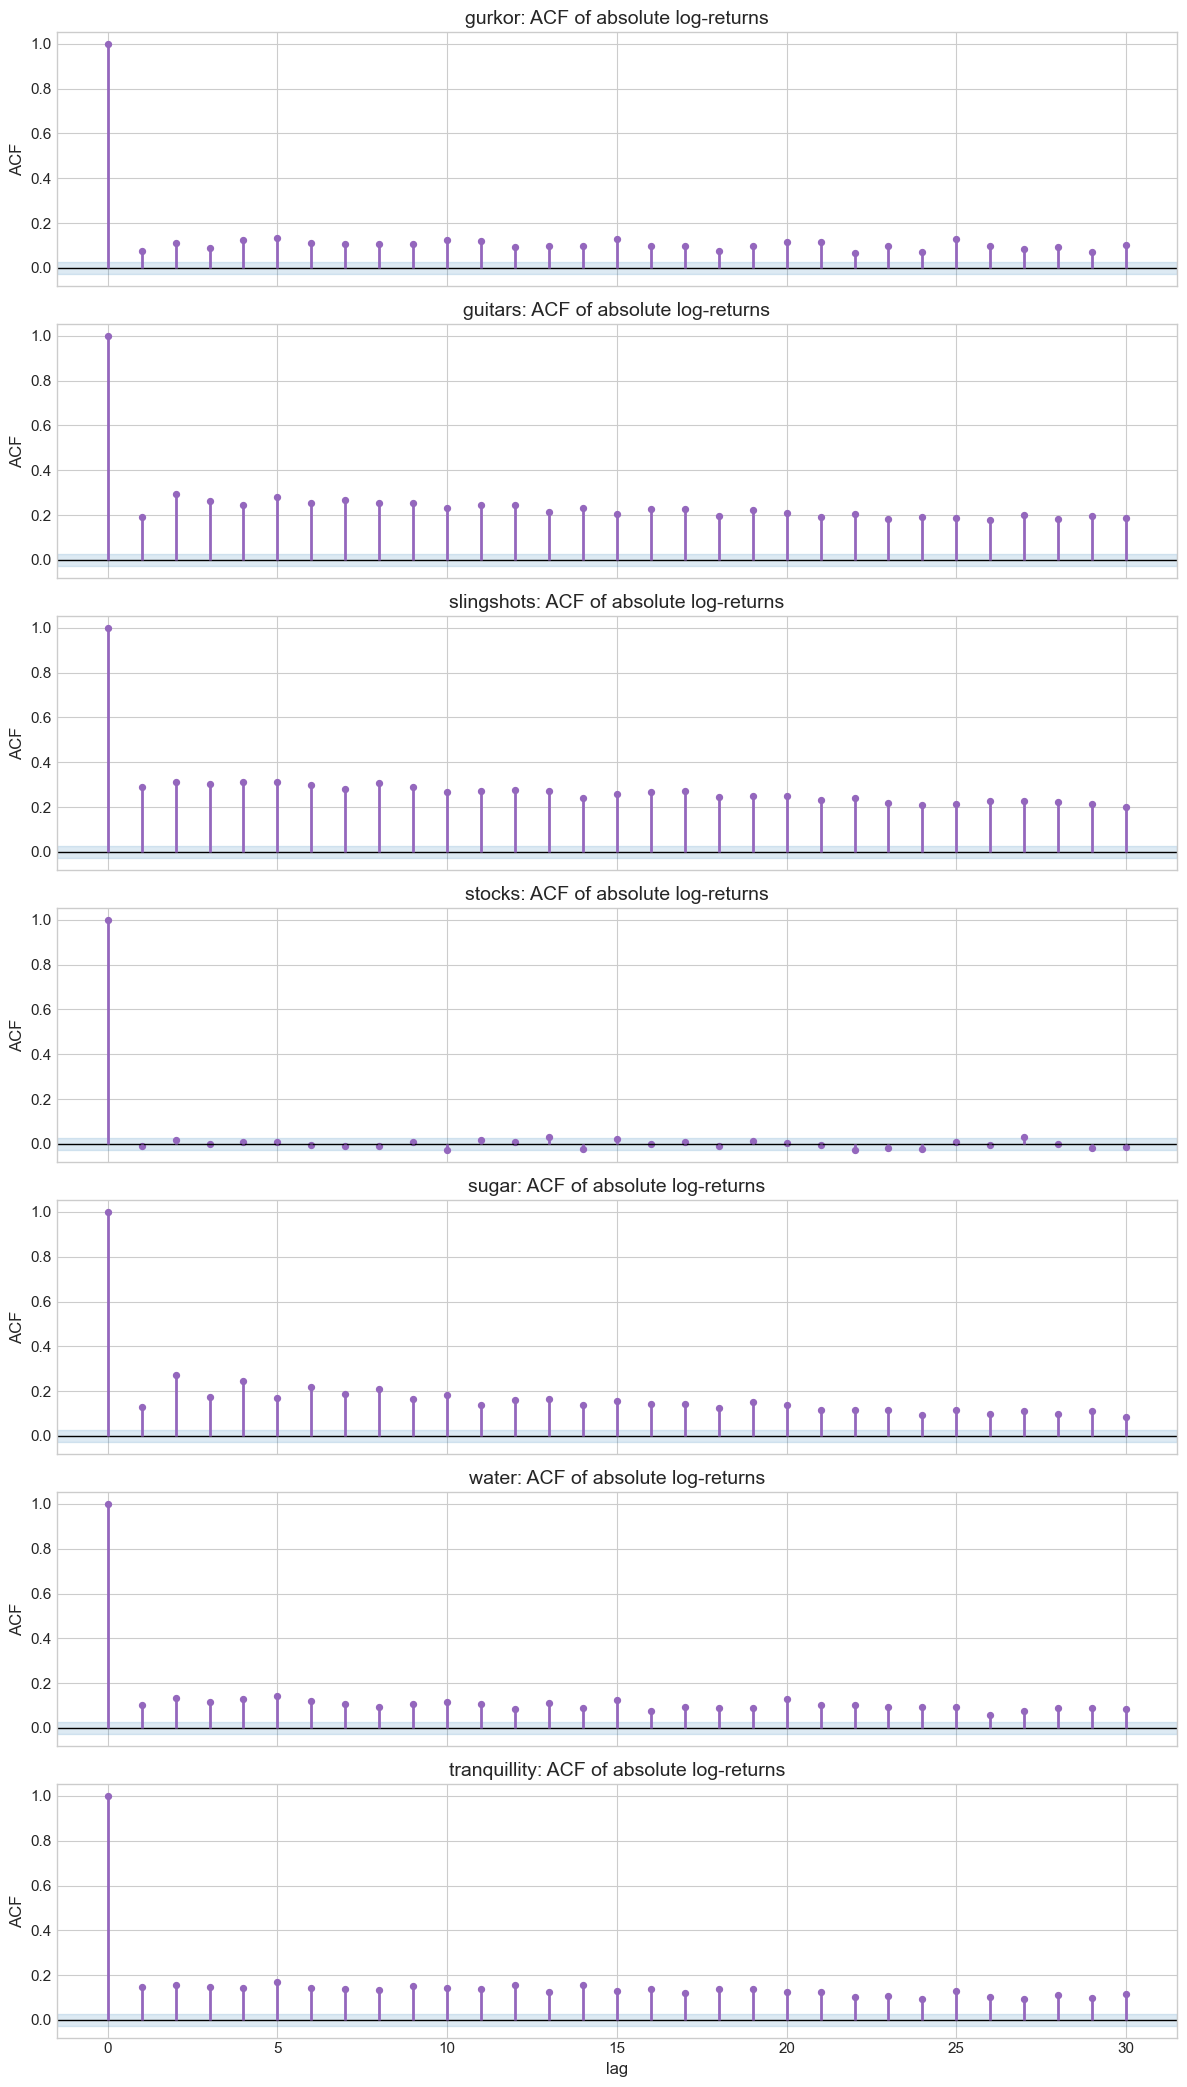

,strongest_lag,acf_at_strongest_lag,significant_lags_up_to_30
series,,,
gurkor,5,0.134493,30
guitars,2,0.294236,30
slingshots,5,0.314081,30
sugar,2,0.272644,30
water,5,0.143166,30
tranquillity,5,0.170896,30
stocks,13,0.029548,3


In [14]:
def sample_acf(series, max_lag=30):
    series = series.dropna()
    centered = series - series.mean()
    values = centered.to_numpy()

    if len(values) <= max_lag:
        raise ValueError("Series is too short for the requested number of lags.")

    denominator = np.dot(values, values)
    acf_values = [1.0]

    for lag in range(1, max_lag + 1):
        numerator = np.dot(values[lag:], values[:-lag])
        acf_values.append(numerator / denominator)

    return np.array(acf_values)


max_lag = 30
lags = np.arange(max_lag + 1)
fig, axes = plt.subplots(len(log_returns.columns), 1, figsize=(12, 3 * len(log_returns.columns)), sharex=True)

for ax, column in zip(np.atleast_1d(axes), log_returns.columns):
    series = np.abs(log_returns[column].dropna())
    acf_values = sample_acf(series, max_lag=max_lag)
    confidence_band = 1.96 / np.sqrt(len(series))

    ax.axhline(0, color="black", linewidth=1)
    ax.axhspan(-confidence_band, confidence_band, color="tab:blue", alpha=0.15)
    ax.vlines(lags, 0, acf_values, color="tab:purple", linewidth=2)
    ax.scatter(lags, acf_values, color="tab:purple", s=18)
    ax.set_title(f"{column}: ACF of absolute log-returns")
    ax.set_ylabel("ACF")

np.atleast_1d(axes)[-1].set_xlabel("lag")
plt.tight_layout()
plt.show()

acf_summary = []
for column in log_returns.columns:
    series = np.abs(log_returns[column].dropna())
    acf_values = sample_acf(series, max_lag=max_lag)
    confidence_band = 1.96 / np.sqrt(len(series))
    significant_lags = [lag for lag in range(1, max_lag + 1) if abs(acf_values[lag]) > confidence_band]
    strongest_lag = int(np.argmax(np.abs(acf_values[1:])) + 1)

    acf_summary.append({
        "series": column,
        "strongest_lag": strongest_lag,
        "acf_at_strongest_lag": acf_values[strongest_lag],
        "significant_lags_up_to_30": len(significant_lags)
    })

pd.DataFrame(acf_summary).set_index("series").sort_values("significant_lags_up_to_30", ascending=False)


For absolute returns, significant positive autocorrelation is usually interpreted as evidence of volatility clustering rather than predictability in the sign of returns. In other words, if several lags exceed the `\pm 1.96 / \sqrt{T}` band, the series looks noisy in persistent bursts, not necessarily directionally predictable.


In [13]:
price_correlation = prices.corr()
log_return_correlation = log_returns.corr()


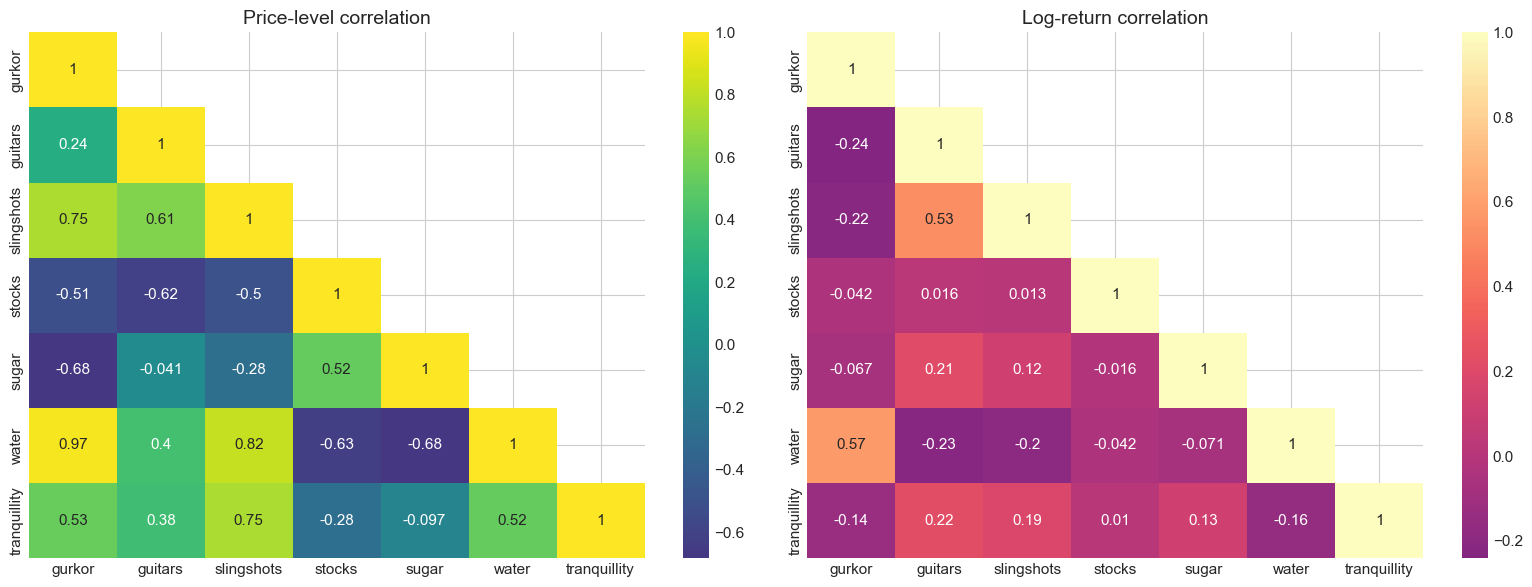

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
mask = np.triu(np.ones_like(price_correlation, dtype=bool), k=1)
sns.heatmap(price_correlation, annot=True, cmap="viridis", ax=axes[0], center=0,mask=mask)
axes[0].set_title("Price-level correlation")

sns.heatmap(log_return_correlation, annot=True, cmap="magma", ax=axes[1], center=0,mask=mask)
axes[1].set_title("Log-return correlation")

plt.tight_layout()
plt.show()


In [15]:
pairs = []
columns = list(log_return_correlation.columns)
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        pairs.append((columns[i], columns[j], log_return_correlation.iloc[i, j]))

pairs = sorted(pairs, key=lambda x: x[2])
least_correlated_pair = pairs[0]
most_correlated_pair = pairs[-1]

pair_summary = pd.DataFrame(
    [least_correlated_pair, most_correlated_pair],
    columns=["asset_1", "asset_2", "log_return_correlation"],
    index=["least_correlated_pair", "most_correlated_pair"]
)
pair_summary


,asset_1,asset_2,log_return_correlation
least_correlated_pair,gurkor,guitars,-0.241075
most_correlated_pair,gurkor,water,0.573293
